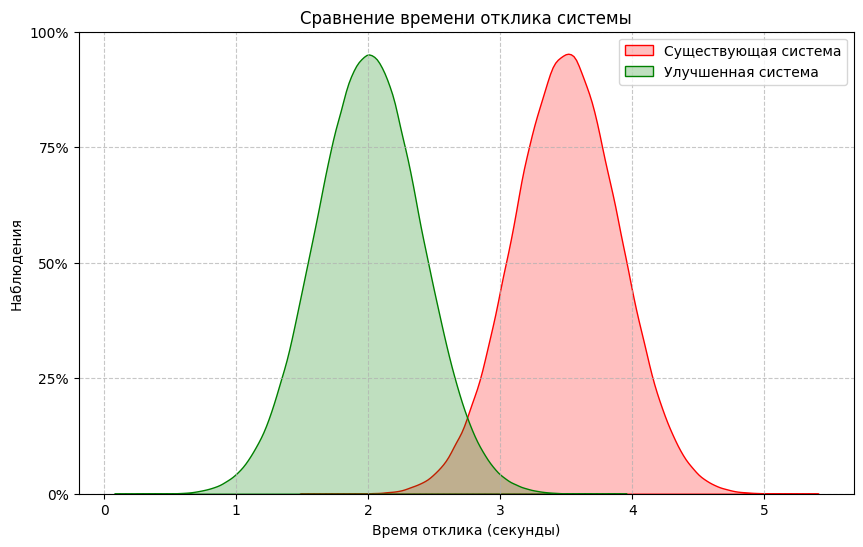

In [4]:
import matplotlib.pyplot as plt; import seaborn as sns; import numpy as np; 

np.random.seed(42); plt.figure(figsize=(10, 6))
existing_system_responses = np.random.normal(loc=3.5, scale=0.4, size=500000)
improved_system_responses = np.random.normal(loc=2.0, scale=0.4, size=500000)
sns.kdeplot(existing_system_responses, label='Существующая система', fill=True, color='red')
sns.kdeplot(improved_system_responses, label='Улучшенная система', fill=True, color='green')
plt.title('Сравнение времени отклика системы'); plt.xlabel('Время отклика (секунды)')
plt.ylabel('Наблюдения'); plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)
ax = plt.gca(); ymin, ymax = ax.get_ylim(); num_ticks = 5; new_yticks = np.linspace(ymin, ymax, num_ticks)
new_yticklabels = [f'{int((tick / ymax) * 100)}%' if ymax != 0 else '0%' for tick in new_yticks]
ax.set_yticks(new_yticks); ax.set_yticklabels(new_yticklabels); plt.show()  

Проведем стат анализ:

In [5]:
existing_mean = np.mean(existing_system_responses)
improved_mean = np.mean(improved_system_responses)

existing_std = np.std(existing_system_responses)
improved_std = np.std(improved_system_responses)

print("-----Общее описание выборок-----")

print(f"Среднее время отклика (текущее): {existing_mean:.4f}")
print(f"Среднее время отклика (улучшеннная система): {improved_mean:.4f}")

print(f"Стандартное отклонение (текущее): {existing_std:.4f}")
print(f"Стандартное отклонение (улучшенная система): {improved_std:.4f}")

-----Общее описание выборок-----
Среднее время отклика (текущее): 3.4995
Среднее время отклика (улучшеннная система): 1.9992
Стандартное отклонение (текущее): 0.4002
Стандартное отклонение (улучшенная система): 0.4000


## Гипотеза
- H0: В улучшенной системе НЕТ статистически значимого уменьшения задержки
- H1: В улучшенной системе есть статистически значимое снижение задержки

для проверки будем использовать Т-тест Уэлча. Статистически значимым будем считать результат при p<0.05

In [9]:
from scipy.stats import ttest_ind

t_statistic, p_value = ttest_ind(
    existing_system_responses,
    improved_system_responses,
    equal_var=False
)

print("\n---WELCH T-TEST---")

print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.20f}")
if p_value < 0.05:
    print("Нулевая гипотеза отвергается")
    print("В Улучшенной системе есть статистически значимое уменьшение задержки")
else:
    print("Оставляем нулевую гипотезу")
    print("Нет статистически значимых различий между улучшенной и текущей системой")


print(f'Сокращение задержки: в {existing_mean/improved_mean:.1f} раз')



---WELCH T-TEST---
T-statistic: 1875.0793
P-value: 0.00000000000000000000
Нулевая гипотеза отвергается
В Улучшенной системе есть статистически значимое уменьшение задержки
Сокращение задержки: в 1.8 раз
